In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
ctrl_counts_path = Path(analysis_directory.name) / "control_counts.zarr"
stim_counts_path = Path(analysis_directory.name) / "stimulated_counts.zarr"
ctrl_analysis_path = Path(analysis_directory.name) / "reference.zarr"
stim_analysis_path = Path(analysis_directory.name) / "query.zarr"
repack_store(
    f"{ctrl_path}/data.zarr",
    str(ctrl_counts_path),
    nthreads=2,
)
repack_store(
    f"{stim_path}/data.zarr",
    str(stim_counts_path),
    nthreads=2,
)
ds_ctrl = scarf.mount_datastore(
    str(ctrl_counts_path),
    at=str(ctrl_analysis_path),
    default_assay="RNA",
    nthreads=4,
)
ds_stim = scarf.mount_datastore(
    str(stim_counts_path),
    at=str(stim_analysis_path),
    default_assay="RNA",
    nthreads=4,
)

Downloading bucket files: 47086495 / 47086495 complete

Downloading bytes: 47086495 / 47086495 complete

Downloading bucket files: 53938394 / 53938394 complete

Downloading bytes: 53938394 / 53938394 complete

Repacking RNA/counts: 2 / 2 complete

...

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

Repacking RNA/counts: 2 / 2 complete

  RNA/counts: shape=(10111, 35635), dtype=uint32, chunks=(7015, 3532), shards=(7015, 38852)


In [2]:
ds_ctrl.cells.insert(
    "reference_batch",
    np.repeat("control", ds_ctrl.cells.N),
    overwrite=True,
)

In [3]:
artifacts = ds_ctrl.pipeline.run(
    filtering=False,
    cell_cycle_scoring=False,
    highly_variable_features={
        "min_cells": 10,
        "top_n": 2000,
        "min_mean": -3,
        "max_mean": 2,
        "max_var": 6,
    },
    pca={"dims": 25},
    harmony={"batch_columns": ["reference_batch"]},
    neighbors={"k": 17},
    umap=False,
    leiden={},
    paris=False,
    doublet_scoring=False,
    markers=False,
)
reference = ds_ctrl.build_mapping_reference(artifacts["neighbors"])
pd.Series(
    {
        "method": reference.method,
        "assay": reference.assay_name,
        "feature_selection": reference.feature_selection,
        "selected_cells": reference.selected_cell_count,
        "n_features": reference.model.n_features,
        "n_dims": reference.model.n_dims,
        "has_symphony_state": reference.symphony_state is not None,
    },
    name="mapping_reference",
)

Calculating feature statistics: 56 / 56 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

...

Harmonizing batches: 50 / 50 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

method                                                         symphony
assay                                                               RNA
feature_selection     ArtifactRef(assay='RNA', kind='feature_selecti...
selected_cells                                                     8486
n_features                                                         2000
n_dims                                                               25
has_symphony_state                                                 True
Name: mapping_reference, dtype: object

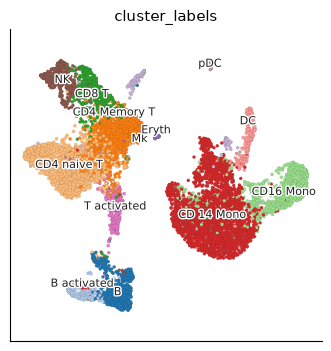

In [4]:
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)

In [5]:
reference = ds_ctrl.get_mapping_reference()
pd.Series(
    {
        "method": reference.method,
        "assay": reference.assay_name,
        "selected_cells": reference.selected_cell_count,
        "n_features": reference.model.n_features,
        "n_dims": reference.model.n_dims,
        "has_symphony_state": reference.symphony_state is not None,
    },
    name="reloaded_mapping_reference",
)

method                symphony
assay                      RNA
selected_cells            8486
n_features                2000
n_dims                      25
has_symphony_state        True
Name: reloaded_mapping_reference, dtype: object

In [6]:
query_batches = pd.DataFrame(
    {
        "reference_batch": np.repeat(
            "stimulated",
            len(ds_stim.cells.fetch("ids", key="I")),
        )
    }
)
mapping = ds_stim.run_mapping(
    reference,
    "stim_atlas",
    query_assay="RNA",
    save_k=5,
    query_batches=query_batches,
)
mapping.mapping_name, mapping.n_cells, mapping.correction_method

('stim_atlas', 10111, 'symphony')

In [7]:
mapped = ds_stim.get_mapping_result(
    "stim_atlas",
    reference=reference,
    query_assay="RNA",
    load_arrays=True,
)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'symphony',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.2241435271304766}

In [8]:
transferred = ds_stim.get_target_classes(
    mapped,
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "atlas_labels",
    transferred.to_numpy(),
    overwrite=True,
)
accepted = transferred.notna() & transferred.ne("NA")
accepted.value_counts().rename(
    index={True: "accepted", False: "abstained"}
).rename("query cells")

accepted     8468
abstained    1643
Name: query cells, dtype: int64

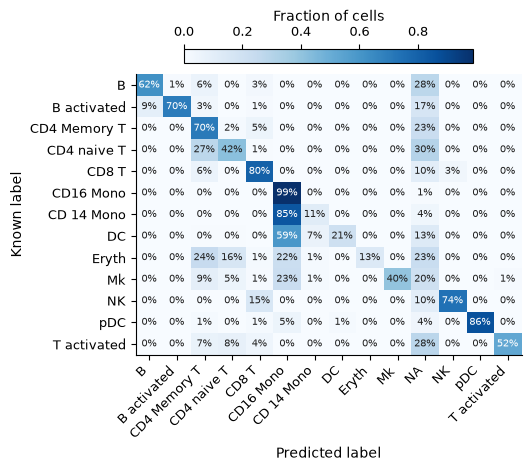

In [9]:
query_labels = np.asarray(ds_stim.cells.fetch("cluster_labels")).astype(str)
ds_stim.plots.mapping_confusion(
    mapped,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    normalize="true",
    threshold_fraction=0.6,
)

In [10]:
focus_labels = ("CD4 Memory T", "CD 14 Mono", "NK")
focus_groups = np.array(
    [label if label in focus_labels else "other" for label in query_labels],
    dtype=object,
)
assert mapped.reference is not None
ref_classes = np.asarray(
    mapped.reference.fetch_cell_column("cluster_labels"),
    dtype=object,
)
score_mass: dict[str, pd.Series] = {}
for group, values in ds_stim.get_mapping_score(
    mapped,
    target_groups=focus_groups,
    log_transform=False,
):
    if group == "other":
        continue
    score_mass[str(group)] = (
        pd.Series(np.asarray(values, dtype=np.float64), index=ref_classes)
        .groupby(level=0, sort=False)
        .sum()
    )
score_mass_table = pd.DataFrame(
    {label: score_mass[label] for label in focus_labels if label in score_mass}
).fillna(0.0)
score_mass_table.loc[
    score_mass_table.max(axis=1).sort_values(ascending=False).index
].round(3)

,CD4 Memory T,CD 14 Mono,NK
CD16 Mono,0.043,298.616,0.000
NK,0.048,0.000,242.017
CD4 Memory T,241.320,0.170,2.178
CD8 T,45.744,0.510,66.056
CD 14 Mono,0.000,52.278,0.144
CD4 naive T,41.783,0.352,2.447
T activated,0.638,0.000,0.137
Mk,0.224,0.000,0.390
B,0.000,0.000,0.137
DC,0.000,0.051,0.000


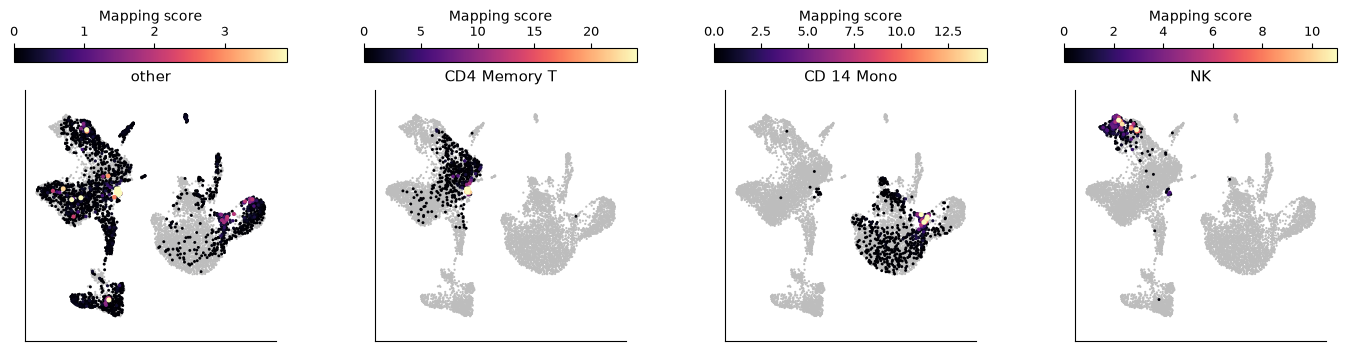

In [11]:
ds_stim.plots.mapping_score(
    mapped,
    layout_key="RNA_UMAP",
    target_groups=focus_groups,
    size_by_score=True,
    log_transform=False,
    figsize=(14, 3.4),
)